<a href="https://colab.research.google.com/github/tonycuenca99-hue/ARQUIVOS-IA/blob/main/AULA_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#importar bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

In [2]:
#load the data
from google.colab import files
uploaded=files.upload()

Saving iiot_30min_norm.csv to iiot_30min_norm.csv


In [3]:
# read csv file
filename= list(uploaded.keys())[0]
df=pd.read_csv(filename)


In [4]:
df

,TIME,FM1,PE1,PE2,PE3,PE4,TP1,TP2,EPOCH
0,2020-07-05 21:00:00+00:00,0.291841,0.944212,0.969845,0.909817,0.752879,0.128703,0.729592,1593982800
1,2020-07-05 21:30:00+00:00,0.290384,0.947971,0.971459,0.913576,0.753741,0.117572,0.723905,1593984600
2,2020-07-05 22:00:00+00:00,0.279458,0.944138,0.968994,0.912516,0.753187,0.111242,0.720671,1593986400
3,2020-07-05 22:30:00+00:00,0.288927,0.950337,0.976253,0.915991,0.756699,0.102464,0.716186,1593988200
4,2020-07-05 23:00:00+00:00,0.299610,0.950226,0.975747,0.916188,0.756563,0.093201,0.711454,1593990000
...,...,...,...,...,...,...,...,...,...
715,2020-07-20 18:30:00+00:00,0.509871,0.926097,0.954982,0.902386,0.827435,0.459539,0.611203,1595269800
716,2020-07-20 19:00:00+00:00,0.494696,0.925443,0.952851,0.902522,0.825390,0.429196,0.602910,1595271600
717,2020-07-20 19:30:00+00:00,0.483042,0.927908,0.953430,0.902238,0.827238,0.355604,0.584250,1595273300
718,2020-07-20 20:00:00+00:00,0.495382,0.925821,0.952846,0.899702,0.824158,0.325662,0.559331,1595275300


In [6]:
#ESTANDARIZAR OS DADOS
scaler=StandardScaler()
# Exclude the 'TIME' column before scaling
numerical_cols = df.select_dtypes(include=np.number).columns
df_scaled = scaler.fit_transform(df[numerical_cols])

In [7]:
df_scaled

array([[-0.96755582,  1.25543255,  0.23786125, ..., -1.13689005,
         0.88839513, -1.72964785],
       [-0.98042033,  1.80086809,  0.27938773, ..., -1.18818968,
         0.84727844, -1.72483659],
       [-1.07690506,  1.24469411,  0.2159872 , ..., -1.21736424,
         0.82389535, -1.72002533],
       ...,
       [ 0.72092862, -1.11049116, -0.18436137, ..., -0.09111423,
        -0.16247457,  1.71975804],
       [ 0.8299037 , -1.41337304, -0.19938743, ..., -0.2291149 ,
        -0.34264559,  1.72510389],
       [ 0.82767636, -1.56684558, -0.29847475, ..., -0.35617044,
        -0.42193768,  1.72964785]])

In [9]:
#aplicar metodo pca
pca=PCA()
X_pca=pca.fit_transform(df_scaled)

In [10]:
pca.explained_variance_ratio_

array([0.28668503, 0.20978444, 0.14005258, 0.13674837, 0.11524202,
       0.08247745, 0.02451552, 0.0044946 ])

In [13]:
#criar dataframe dos resultados do PCA
df_pca=pd.DataFrame(X_pca,index=samples_indices, columns= [f"PC{i+1}" for i in range (X_pca.shape[1])])

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
0,-0.472838,-0.547886,-1.709862,-0.766196,-1.999242,0.051515,-0.286359,-0.206712
1,-0.616322,-0.576203,-1.876633,-0.519469,-2.272400,0.392036,-0.255785,-0.104623
2,-0.423466,-0.631740,-1.682645,-0.696989,-2.086704,-0.011146,-0.299212,-0.233015
3,-0.693344,-0.630992,-1.905595,-0.399819,-2.489647,0.648813,-0.245083,-0.001666
4,-0.736918,-0.689085,-1.886160,-0.401131,-2.421502,0.679724,-0.272684,-0.020636
...,...,...,...,...,...,...,...,...
715,0.519823,0.527047,1.363253,0.308064,1.803178,-0.186740,-0.720397,0.391893
716,0.533516,0.420892,1.399871,0.340319,1.729631,-0.364932,-0.768805,0.354669
717,0.357016,0.160989,1.342391,0.536923,1.424455,-0.266508,-0.858493,0.502393
718,0.283065,-0.027150,1.545076,0.444140,1.597058,-0.442223,-0.888243,0.399883


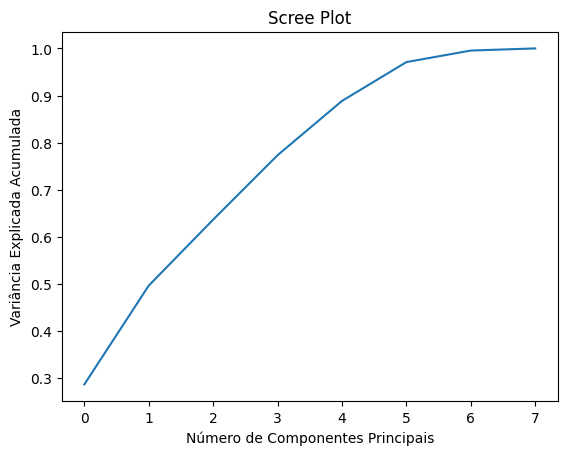

In [16]:
#visualizar scree plot
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("Número de Componentes Principais")
plt.ylabel("Variância Explicada Acumulada")
plt.title("Scree Plot")
plt.show()

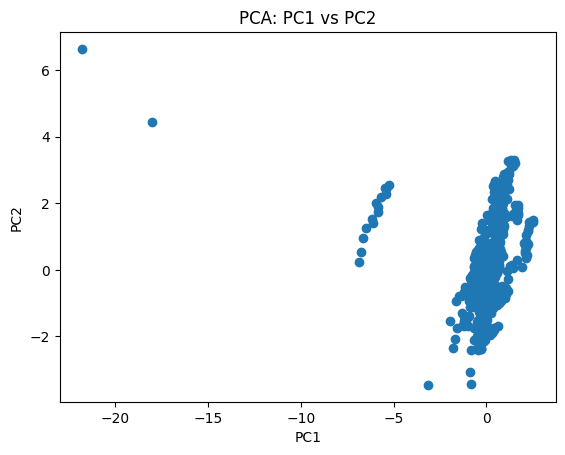

In [18]:
#visualizar plot PCA PC1 X PC2
plt.scatter(df_pca["PC1"], df_pca["PC2"])
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA: PC1 vs PC2") # Added a title for clarity
plt.show()